# Modeling Pipeline – Job Ranking System

## 1. Exploratory Data Analysis (EDA)
The dataset is analyzed to understand the relationship between candidates (CVs) and job descriptions.  
Each CV is associated with multiple job postings, and the objective is to **rank jobs per CV** according to relevance.  
The target variable is binary (relevant / not relevant) and serves as supervision for learning the ranking signal.

---

## 2. Data Preprocessing and Group-Based Splitting
Feature engineering is performed to capture skill matching, missing skills, and domain information.  
To prevent data leakage and ensure realistic evaluation, data is split **at the CV level** using group-based splitting
(`GroupShuffleSplit`), ensuring that all job postings associated with a given CV appear in the same split.

---

## 3. Pointwise Learning-to-Rank with Logistic Regression (Baseline)
The ranking task is modeled using a **pointwise learning-to-rank approach**, where a scoring function is learned for
each (CV, Job) pair:

(CV, Job) → relevance score

As a baseline, **Logistic Regression** is used to predict the probability of relevance.  
This probability is treated as a **continuous relevance score**, which is then used to rank jobs per CV.

The model is trained using **log loss (binary cross-entropy)** as a **surrogate objective**, providing a simple,
interpretable, and stable baseline for ranking.

---

## 4. Ranking-Based Evaluation
Predicted relevance scores are used to generate ranked job lists **per CV**.  
Ranking quality is evaluated using metrics designed for recommendation systems:
- **Mean Reciprocal Rank (MRR)**
- **Precision@K**

These metrics directly reflect how early relevant jobs appear in the ranked lists and align with the final
recommendation objective.

---

## 5. Learning Curve and Bias–Variance Analysis
Learning curves are constructed by training the model on increasing fractions of CVs and evaluating ranking
performance using MRR.  
This analysis is used to study generalization behavior and to determine whether performance is limited by
training data size or by feature expressiveness.

---

## 6. Model Comparison
More expressive scoring models are evaluated under the same ranking framework and compared against the
Logistic Regression baseline.  
Results indicate that learning a continuous relevance score is more appropriate for ranking than treating
the task as a pure classification problem.

---

## 7. Conclusion
The task is inherently a **ranking problem**, where the goal is to order job descriptions per candidate rather
than predict independent class labels.  
A pointwise scoring-based approach with Logistic Regression provides a strong and interpretable baseline,
while ranking-aware evaluation metrics (MRR and Precision@K) ensure alignment with the recommendation objective.

---

## Future Work
Future extensions may explore **pairwise** or **listwise learning-to-rank objectives**
(e.g., RankSVM or LambdaMART) to directly optimize ranking quality and better capture relative relevance signals.


In [ ]:
!pip install scikit-optimize
!pip install skopt
!pip install --upgrade pip
!pip install scikit-optimize
!pip install xgboost

In [ ]:
!pip install seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
from sklearn.preprocessing import PolynomialFeatures,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit


# Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv(r"C:\Users\Zakaria\Downloads\project_ml\Job_Recommendation_System\Data\processed\final_df_with_cnn.csv")
df.head()

,cv_id,jd_id,matched_weight,required_weight,match_ratio,missing_required_skills_count,missing_hard_skills,missing_soft_skills,required_hard_skills,required_soft_skills,...,feat_68,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8
0,1,1,1,1,1.000000,0,[],['adaptability'],['ai'],"['teamwork', 'leadership', 'customer focus', '...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
1,1,2,3,4,0.750000,1,['systems engineering'],"['communication', 'problem solving']","['ai', 'systems engineering', 'financial analy...","['communication', 'problem solving']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
2,1,3,1,3,0.333333,2,"['marketing', 'microsoft office']",[],"['ai', 'marketing', 'microsoft office']","['teamwork', 'leadership', 'growth mindset']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
3,1,4,1,3,0.333333,2,"['sales', 'product management']","['problem solving', 'time management', 'work e...","['ai', 'sales', 'product management']","['problem solving', 'leadership', 'time manage...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
4,1,5,5,8,0.625000,3,"['networking', 'sales', 'product management']","['problem solving', 'adaptability', 'attention...","['ai', 'models', 'reporting', 'networking', 's...","['teamwork', 'problem solving', 'leadership', ...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967


In [3]:
df.columns

Index(['cv_id', 'jd_id', 'matched_weight', 'required_weight', 'match_ratio',
       'missing_required_skills_count', 'missing_hard_skills',
       'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_new', 'missing_soft_skills_count_new', 'domain',
       'final_score', 'target', 'video_id', 'feat_95', 'feat_69', 'feat_125',
       'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76', 'feat_11',
       'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78', 'feat_8'],
      dtype='object')

In [4]:
df.shape

(10176, 33)

In [5]:
print(f" number cvs : {df['cv_id'].nunique()}, number jd: {df['jd_id'].nunique()}")

 number cvs : 32, number jd: 318


In [6]:
df['target'].value_counts()

target
0    7809
1    2367
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10176 entries, 0 to 10175
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cv_id                          10176 non-null  int64  
 1   jd_id                          10176 non-null  int64  
 2   matched_weight                 10176 non-null  int64  
 3   required_weight                10176 non-null  int64  
 4   match_ratio                    10176 non-null  float64
 5   missing_required_skills_count  10176 non-null  int64  
 6   missing_hard_skills            10176 non-null  object 
 7   missing_soft_skills            10176 non-null  object 
 8   required_hard_skills           10176 non-null  object 
 9   required_soft_skills           10176 non-null  object 
 10  required_skill_count           10176 non-null  int64  
 11  soft_skill_match_score         10176 non-null  float64
 12  missing_soft_skills_new        10176 non-null 

In [8]:
df.describe()

,cv_id,jd_id,matched_weight,required_weight,match_ratio,missing_required_skills_count,required_skill_count,soft_skill_match_score,missing_soft_skills_count_new,final_score,...,feat_68,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8
count,10176.000000,10176.00000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,...,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000
mean,16.500000,159.50000,2.697229,8.056604,0.355347,5.359375,14.930818,0.653857,2.589524,0.480781,...,2.161799,-2.735674,-1.148053,-0.520676,1.453815,2.034798,0.257880,-1.894128,-0.212491,-2.034668
std,9.233546,91.80275,1.854569,3.711876,0.211519,3.169213,5.594656,0.204594,3.106187,0.161117,...,1.627662,1.545722,1.511170,1.449669,1.761731,1.929322,2.058547,1.404351,1.657655,2.213251
min,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.864953,-5.702461,-4.367168,-2.321454,-1.294435,-0.721812,-3.909988,-5.804455,-2.693511,-7.364284
25%,8.750000,80.00000,1.000000,5.000000,0.200000,3.000000,11.000000,0.493783,0.000000,0.362323,...,1.157120,-3.605802,-2.523793,-1.494455,-0.013226,0.452038,-1.757183,-2.451491,-1.780795,-3.442146
50%,16.500000,159.50000,2.000000,8.000000,0.333333,5.000000,15.000000,0.686420,1.000000,0.472729,...,1.797171,-2.727473,-0.871984,-0.475769,1.464662,1.816334,0.553244,-1.821362,-0.660611,-1.670098
75%,24.250000,239.00000,4.000000,11.000000,0.500000,7.000000,19.000000,0.817824,5.000000,0.589868,...,3.030903,-1.692451,-0.186382,-0.026943,2.640111,3.317204,1.931814,-1.115498,1.248693,-0.360628
max,32.000000,318.00000,12.000000,19.000000,1.000000,19.000000,29.000000,1.000000,12.000000,1.000000,...,5.915772,0.949180,1.327962,4.269791,6.336426,7.308219,3.683286,0.918401,2.939344,1.230159


In [9]:
selected_cols = [
       'match_ratio','missing_required_skills_count',
       'required_skill_count','missing_soft_skills_count_new',
       'domain', 'video_id', 'feat_95', 'feat_69', 'feat_125',
       'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76', 'feat_11',
       'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78', 'feat_8','target'
]

df_model = df[selected_cols].copy()

df_model.head()

,match_ratio,missing_required_skills_count,required_skill_count,missing_soft_skills_count_new,domain,video_id,feat_95,feat_69,feat_125,feat_20,...,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,target
0,1.000000,0,5,0,Support,1,-1.322632,1.406155,-2.846429,1.291473,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
1,0.750000,1,6,1,IT,1,-1.322632,1.406155,-2.846429,1.291473,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
2,0.333333,2,6,0,Business,1,-1.322632,1.406155,-2.846429,1.291473,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
3,0.333333,2,9,1,Business,1,-1.322632,1.406155,-2.846429,1.291473,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
4,0.625000,3,18,2,Business,1,-1.322632,1.406155,-2.846429,1.291473,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1


In [10]:
len(df_model['domain'].unique())

13

In [11]:
df_model['domain'].value_counts()

domain
IT                2240
Engineering       2080
Business          1504
Finance           1248
HR                1184
Support            576
Administrative     416
Research           256
Management         192
Operations         160
Analytics          128
Creative            96
Consulting          96
Name: count, dtype: int64

In [12]:
#encode domain
df_model_encoded = pd.get_dummies(
    df_model,
    columns=['domain'],
    prefix='domain'
)
bool_cols = df_model_encoded.select_dtypes(include='bool').columns
df_model_encoded[bool_cols] = df_model_encoded[bool_cols].astype(int)

In [13]:
df_model_encoded.head()

,match_ratio,missing_required_skills_count,required_skill_count,missing_soft_skills_count_new,video_id,feat_95,feat_69,feat_125,feat_20,feat_91,...,domain_Consulting,domain_Creative,domain_Engineering,domain_Finance,domain_HR,domain_IT,domain_Management,domain_Operations,domain_Research,domain_Support
0,1.000000,0,5,0,1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,0,0,0,0,0,0,0,0,0,1
1,0.750000,1,6,1,1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,0,0,0,0,0,1,0,0,0,0
2,0.333333,2,6,0,1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,0,0,0,0,0,0,0,0,0,0
3,0.333333,2,9,1,1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,0,0,0,0,0,0,0,0,0,0
4,0.625000,3,18,2,1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,0,0,0,0,0,0,0,0,0,0


In [14]:
df_model_encoded.describe()

,match_ratio,missing_required_skills_count,required_skill_count,missing_soft_skills_count_new,video_id,feat_95,feat_69,feat_125,feat_20,feat_91,...,domain_Consulting,domain_Creative,domain_Engineering,domain_Finance,domain_HR,domain_IT,domain_Management,domain_Operations,domain_Research,domain_Support
count,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,...,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000
mean,0.355347,5.359375,14.930818,2.589524,16.500000,-0.488710,0.562177,-2.982411,0.989733,1.569688,...,0.009434,0.009434,0.204403,0.122642,0.116352,0.220126,0.018868,0.015723,0.025157,0.056604
std,0.211519,3.169213,5.594656,3.106187,9.233546,1.361514,1.374077,1.964801,1.925915,2.728051,...,0.096674,0.096674,0.403284,0.328041,0.320663,0.414352,0.136065,0.124409,0.156610,0.231095
min,0.000000,0.000000,0.000000,0.000000,1.000000,-4.268386,-1.553395,-7.444741,-4.796014,-3.821225,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,3.000000,11.000000,0.000000,8.750000,-1.334173,-0.295707,-4.275203,0.297454,0.017017,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.333333,5.000000,15.000000,1.000000,16.500000,-0.493819,0.361695,-3.095893,1.499649,1.189473,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,7.000000,19.000000,5.000000,24.250000,0.251136,1.414726,-1.154551,2.252898,3.039532,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,19.000000,29.000000,12.000000,32.000000,2.660940,4.294547,0.085521,3.823320,10.495974,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df_model_encoded.columns

Index(['match_ratio', 'missing_required_skills_count', 'required_skill_count',
       'missing_soft_skills_count_new', 'video_id', 'feat_95', 'feat_69',
       'feat_125', 'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76',
       'feat_11', 'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78',
       'feat_8', 'target', 'domain_Administrative', 'domain_Analytics',
       'domain_Business', 'domain_Consulting', 'domain_Creative',
       'domain_Engineering', 'domain_Finance', 'domain_HR', 'domain_IT',
       'domain_Management', 'domain_Operations', 'domain_Research',
       'domain_Support'],
      dtype='object')

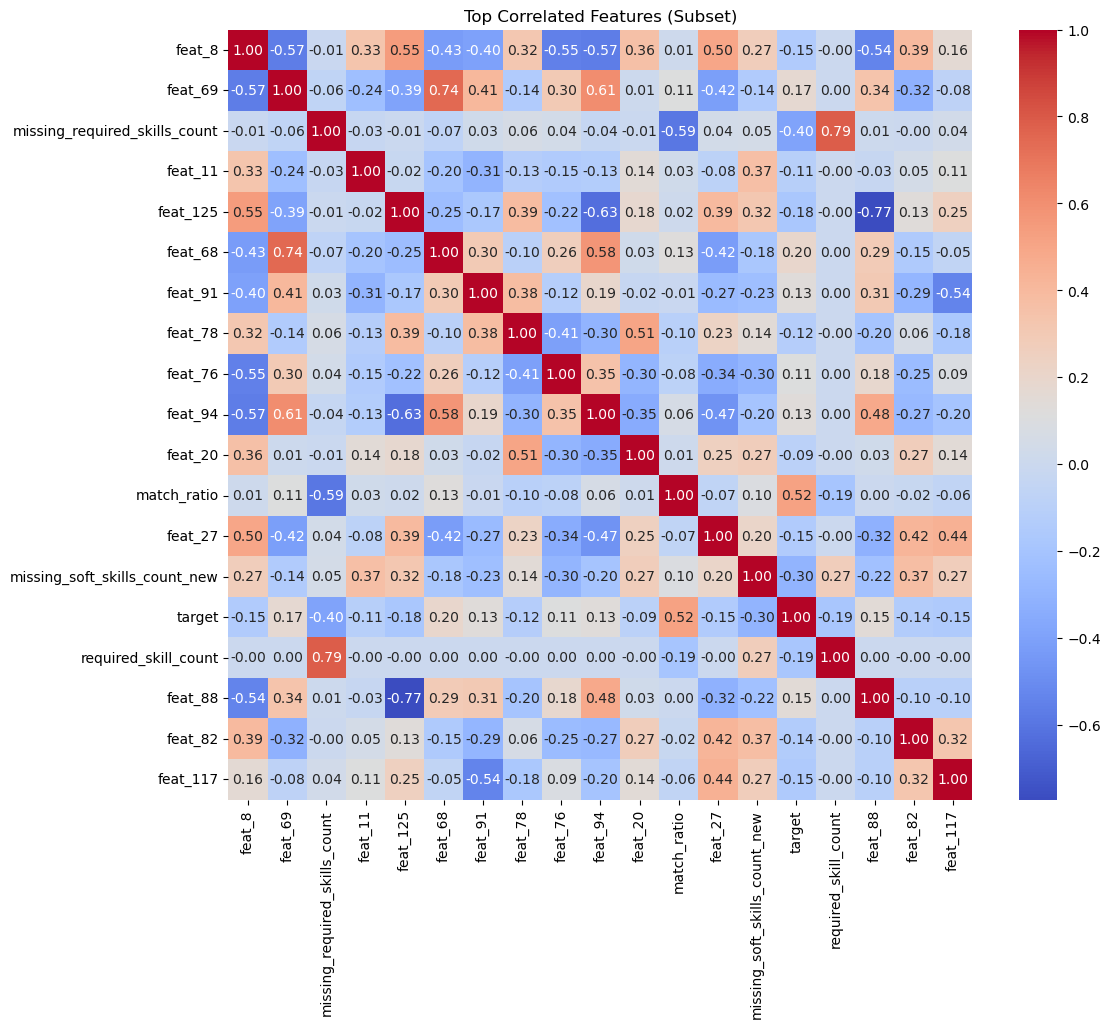

In [16]:
corr = df_model_encoded.corr()
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

top_20_corr = corr_pairs.head(20)

top_20_df = top_20_corr.reset_index()
top_20_df.columns = ['Feature 1', 'Feature 2', 'Correlation']

top_features = list(set(top_20_df['Feature 1']).union(set(top_20_df['Feature 2'])))

corr_subset = corr.loc[top_features, top_features]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top Correlated Features (Subset)')
plt.show()

In [17]:
df_model_encoded.corr(numeric_only=True)['target'].sort_values(ascending=False).head(20)

target                   1.000000
match_ratio              0.516234
feat_68                  0.196112
domain_HR                0.182506
feat_69                  0.173417
domain_Support           0.168112
feat_88                  0.146128
feat_94                  0.130470
feat_91                  0.129583
feat_76                  0.109968
domain_Administrative    0.080153
domain_Creative          0.071389
video_id                 0.059087
domain_Management        0.031352
domain_Operations        0.027640
domain_Business          0.023044
domain_Consulting        0.020860
domain_Research         -0.032003
domain_Analytics        -0.035008
domain_Finance          -0.037789
Name: target, dtype: float64

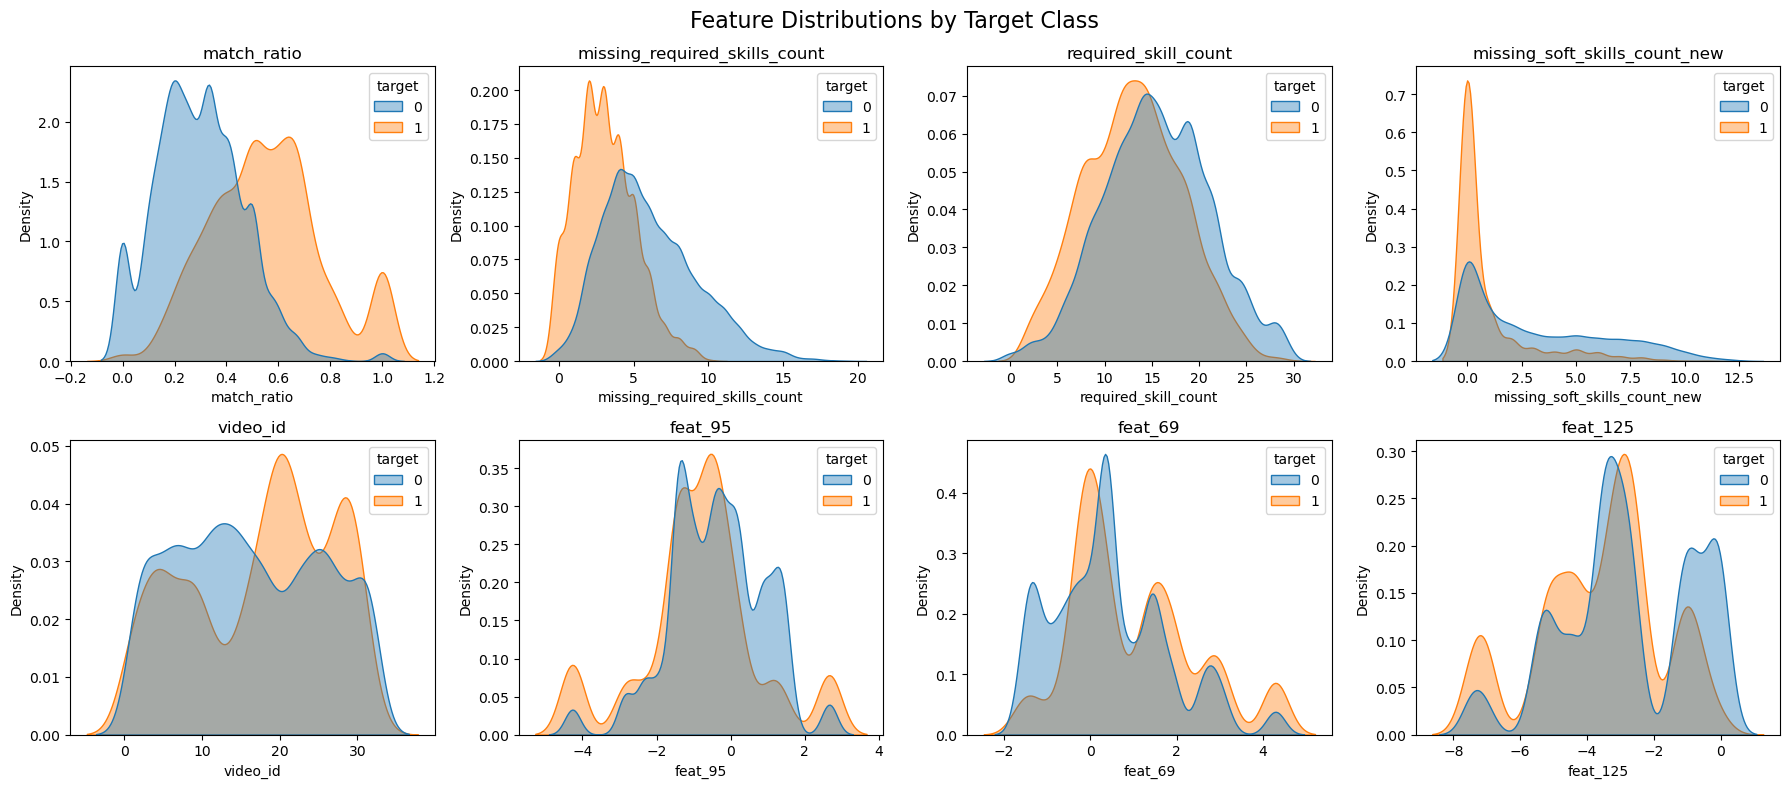

In [18]:
features = [col for col in df_model_encoded.columns if col != "target"]
features = features[:8]
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="target",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=ax
    )
    ax.set_title(feature)
    ax.set_ylabel("Density")


for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Feature Distributions by Target Class", fontsize=16)
plt.tight_layout()
plt.show()

## GroupShuffleSplit performs splitting based on CV IDs (groups),
##### ensuring that all rows belonging to the same CV stay in the same split.

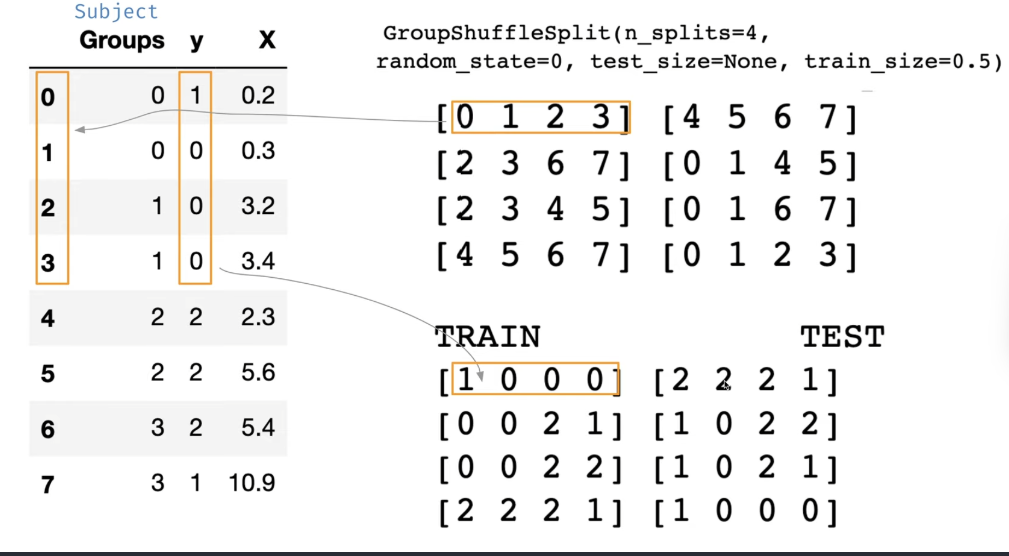

In [19]:
X = df_model_encoded.drop(columns=['target'])
y = df_model_encoded['target']
groups = df['cv_id']
groups.unique() # 15 cv (group)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
      dtype=int64)

In [20]:
gss1 = GroupShuffleSplit(
    test_size=0.35,
    n_splits=1,
    random_state=1000
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
cv_train = groups.iloc[train_idx]

X_ = X.iloc[temp_idx]
y_ = y.iloc[temp_idx]
cv_ = groups.iloc[temp_idx]

In [21]:
gss2 = GroupShuffleSplit(
    test_size=0.5,
    n_splits=1,
    random_state=2024
)

test_idx, val_idx = next(
    gss2.split(X_, y_, groups=cv_)
)

X_test = X_.iloc[test_idx]
y_test = y_.iloc[test_idx]
cv_test = cv_.iloc[test_idx]

X_val = X_.iloc[val_idx]
y_val = y_.iloc[val_idx]
cv_val = cv_.iloc[val_idx]

In [22]:
print(f"train: {X_train.shape[0]}")
print(f"validation: {X_val.shape[0]}")
print(f"test: {X_test.shape[0]}")
print("-"*50)
print(set(cv_train).intersection(set(cv_val)))
print(set(cv_train).intersection(set(cv_test)))
print(set(cv_val).intersection(set(cv_test)))

train: 6360
validation: 1908
test: 1908
--------------------------------------------------
set()
set()
set()


### no CV leakage (set(), set(), set())

In [23]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
val_scores = model.predict_proba(X_val)[:, 1]

val_rank_df = X_val.copy()
val_rank_df['cv_id'] = cv_val.values
val_rank_df['score'] = val_scores
val_rank_df['target'] = y_val.values

val_rank_df = val_rank_df.sort_values(
by = ['cv_id','score'],
ascending = [True,False]
)

val_rank_df.head(318).columns

Index(['match_ratio', 'missing_required_skills_count', 'required_skill_count',
       'missing_soft_skills_count_new', 'video_id', 'feat_95', 'feat_69',
       'feat_125', 'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76',
       'feat_11', 'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78',
       'feat_8', 'domain_Administrative', 'domain_Analytics',
       'domain_Business', 'domain_Consulting', 'domain_Creative',
       'domain_Engineering', 'domain_Finance', 'domain_HR', 'domain_IT',
       'domain_Management', 'domain_Operations', 'domain_Research',
       'domain_Support', 'cv_id', 'score', 'target'],
      dtype='object')

In [25]:
def rank(X,y1,cv,model):
    X_scores = model.predict_proba(X)[:, 1]
    X_rank_df = X.copy()
    X_rank_df['cv_id'] = cv.values
    X_rank_df['score'] = X_scores
    X_rank_df['target'] = y1.values
    X_rank_df = X_rank_df.sort_values(
    by=['cv_id', 'score'],
    ascending=[True, False]
    )
    return X_rank_df

# Evaluation Learn to Rank
## MRR (Mean Reciprocal Rank)
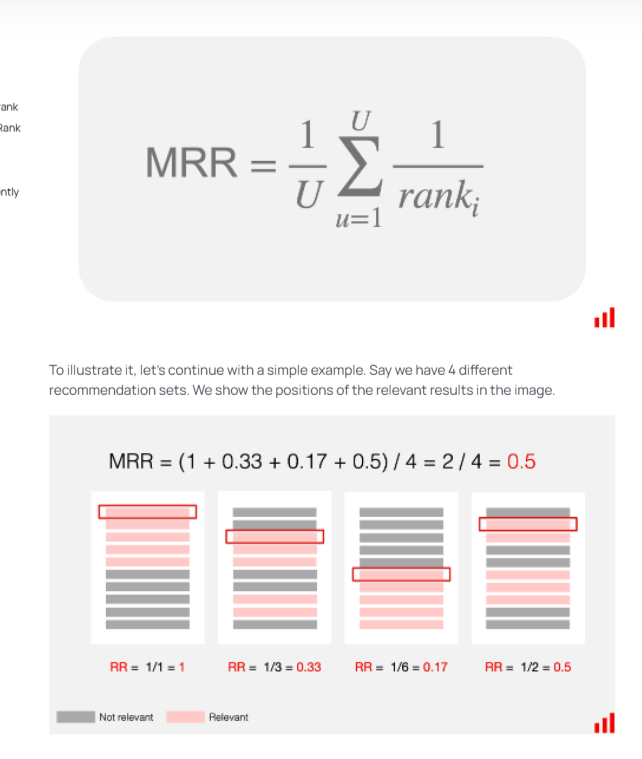

# Precision@k

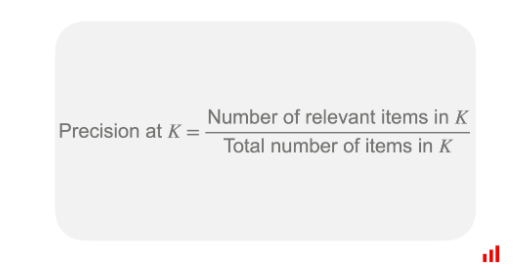

In [26]:
def mean_reciprocal_rank(df):
    rr = []
    for cv, group in df.groupby('cv_id'):
        group = group.reset_index(drop=True)
        relevant = group[group['target'] == 1]

        if len(relevant) == 0:
            continue

        first_rank = relevant.index[0] + 1
        rr.append(1 / first_rank)

    return sum(rr) / len(rr)

In [27]:
def precision_at_k(df, k):
    precisions = []
    for cv, group in df.groupby('cv_id'):
        top_k = group.head(k)
        precisions.append(top_k['target'].mean())


    return sum(precisions) / len(precisions)

In [28]:
mrr_val = mean_reciprocal_rank(val_rank_df)
print("MRR (Validation):", mrr_val)

MRR (Validation): 0.7129629629629629


In [29]:
mrr_v = mean_reciprocal_rank(rank(X_val,y_val,cv_val,model))
mrr_test = mean_reciprocal_rank(rank(X_test,y_test,cv_test,model))
mrr_train = mean_reciprocal_rank(rank(X_train,y_train,cv_train,model))

print(f"val {mrr_v}")
print(f"test {mrr_test}")
print(f"train {mrr_train}")

val 0.7129629629629629
test 0.6964285714285715
train 0.925


In [ ]:
rank(X_test,y_test,cv_test,model)

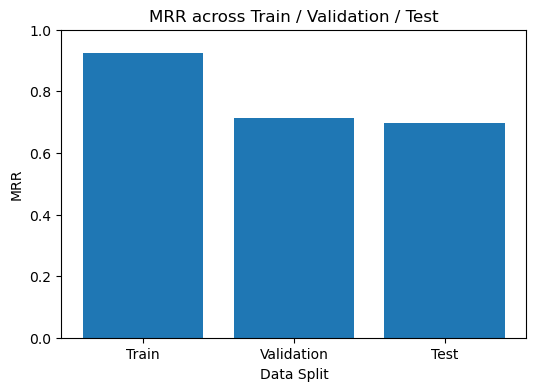

In [30]:
results = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'MRR': [mrr_train, mrr_val, mrr_test]
})

plt.figure(figsize=(6,4))
plt.bar(results['Split'], results['MRR'])
plt.ylim(0, 1)
plt.title('MRR across Train / Validation / Test')
plt.ylabel('MRR')
plt.xlabel('Data Split')
plt.show()

In [31]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_mrrs = []
val_mrrs = []
train_p5 = []
val_p5 = []

unique_cvs = cv_train.unique()
for frac in train_sizes:
    n_cvs = int(len(unique_cvs) * frac)
    selected_cvs = unique_cvs[:n_cvs]
    mask = cv_train.isin(selected_cvs)

    X_sub = X_train[mask]
    y_sub = y_train[mask]
    cv_sub = cv_train[mask]

    model = LogisticRegression(max_iter=1000,class_weight='balanced')
    model.fit(X_sub, y_sub)

    train_rank = rank(X_sub, y_sub, cv_sub,model)
    val_rank = rank(X_val, y_val, cv_val,model)

    train_p5.append(precision_at_k(train_rank, k=5))
    val_p5.append(precision_at_k(val_rank, k=5))

    train_mrrs.append(mean_reciprocal_rank(train_rank))
    val_mrrs.append(mean_reciprocal_rank(val_rank))


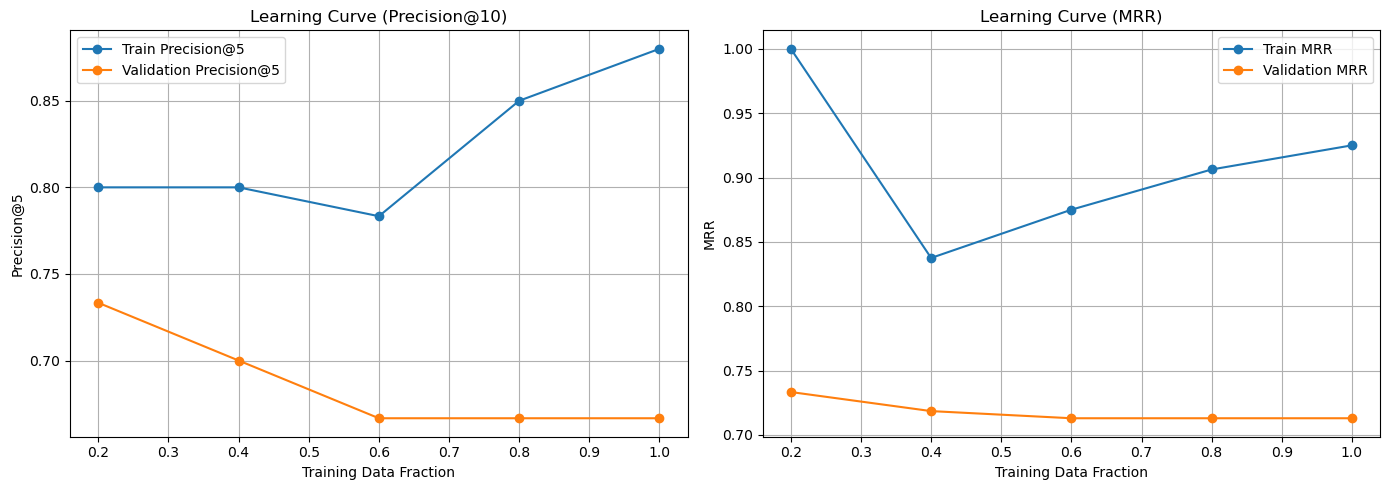

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Plot 1: Precision@10 --------
axes[0].plot(train_sizes, train_p5, marker='o', label='Train Precision@5')
axes[0].plot(train_sizes, val_p5, marker='o', label='Validation Precision@5')

axes[0].set_xlabel("Training Data Fraction")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Learning Curve (Precision@10)")
axes[0].legend()
axes[0].grid(True)

# -------- Plot 2: MRR --------
axes[1].plot(train_sizes, train_mrrs, marker='o', label='Train MRR')
axes[1].plot(train_sizes, val_mrrs, marker='o', label='Validation MRR')

axes[1].set_xlabel("Training Data Fraction")
axes[1].set_ylabel("MRR")
axes[1].set_title("Learning Curve (MRR)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [33]:
# c small --> alpha large -->reduce overfitting
C_values = [0.0001,0.001,0.03,0.01,0.05,100]

results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        penalty='l2',
        class_weight='balanced',
        solver = 'liblinear'
    )

    model.fit(X_train, y_train)

    val_rank = rank(X_val, y_val, cv_val,model)
    val_mrr = mean_reciprocal_rank(val_rank)

    train_rank = rank(X_train, y_train, cv_train,model)
    train_mrr = mean_reciprocal_rank(train_rank)
    results.append({
        'C': C,
        'val_MRR': val_mrr,
        'train_MRR':train_mrr,
        'diff (train,val)' :train_mrr - val_mrr
    })

In [34]:
# with class_weight='balanced'
results_df = pd.DataFrame(results)
results_df

,C,val_MRR,train_MRR,"diff (train,val)"
0,0.0001,0.750000,0.841667,0.091667
1,0.0010,1.000000,0.950000,-0.050000
2,0.0300,0.718519,0.950000,0.231481
3,0.0100,0.861111,0.950000,0.088889
4,0.0500,0.712963,0.925000,0.212037
5,100.0000,0.727778,0.925000,0.197222


In [35]:
C_values = [0.0001,0.001,0.03,0.01,0.05,100]

results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        penalty='l2',
        solver = 'liblinear'
    )

    model.fit(X_train, y_train)

    val_rank = rank(X_val, y_val, cv_val,model)
    val_mrr = mean_reciprocal_rank(val_rank)

    train_rank = rank(X_train, y_train, cv_train,model)
    train_mrr = mean_reciprocal_rank(train_rank)
    results.append({
        'C': C,
        'val_MRR': val_mrr,
        'train_MRR':train_mrr,
        'diff (train,val)' :train_mrr - val_mrr
    })

In [36]:
# without class_weight='balanced'
results_df = pd.DataFrame(results)
results_df

,C,val_MRR,train_MRR,"diff (train,val)"
0,0.0001,0.500000,0.446528,-0.053472
1,0.0010,1.000000,0.925000,-0.075000
2,0.0300,0.720833,0.925000,0.204167
3,0.0100,0.866667,0.950000,0.083333
4,0.0500,0.718519,0.925000,0.206481
5,100.0000,0.727778,0.925000,0.197222


In [37]:
penalties = ["l1", "l2"]
C = 100

results = []

for penalty in penalties:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        class_weight='balanced',
        solver = 'liblinear',
        max_iter=3000,
    )

    model.fit(X_train, y_train)

    # Validation
    val_rank = rank(X_val, y_val, cv_val, model)
    val_mrr = mean_reciprocal_rank(val_rank)

    # Train
    train_rank = rank(X_train, y_train, cv_train, model)
    train_mrr = mean_reciprocal_rank(train_rank)

    results.append({
        "C": C,
        "penalty": penalty,
        "val_MRR": val_mrr,
        "train_MRR": train_mrr,
        "diff (train-val)": train_mrr - val_mrr
    })

results

[{'C': 100,
  'penalty': 'l1',
  'val_MRR': 0.7277777777777779,
  'train_MRR': 0.925,
  'diff (train-val)': 0.1972222222222222},
 {'C': 100,
  'penalty': 'l2',
  'val_MRR': 0.7277777777777779,
  'train_MRR': 0.925,
  'diff (train-val)': 0.1972222222222222}]

In [38]:
final_model = LogisticRegression(
    C=100,
    penalty='l2',
    max_iter=1000,
    class_weight='balanced',
    solver = 'liblinear'
)
final_model.fit(X_train, y_train)

LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

In [39]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_mrrs = []
val_mrrs = []
train_p5 = []
val_p5 = []

unique_cvs = cv_train.unique()

for frac in train_sizes:
    n_cvs = int(len(unique_cvs) * frac)
    selected_cvs = unique_cvs[:n_cvs]

    mask = cv_train.isin(selected_cvs)

    X_sub = X_train[mask]
    y_sub = y_train[mask]
    cv_sub = cv_train[mask]

    final_model = LogisticRegression(C=100,max_iter=1000,
        penalty = 'l2',
        class_weight='balanced',
        solver = 'liblinear'
        )

    final_model.fit(X_sub, y_sub)

    train_rank = rank(X_sub, y_sub, cv_sub,final_model)
    val_rank = rank(X_val, y_val, cv_val,final_model)

    train_p5.append(precision_at_k(train_rank, k=5))
    val_p5.append(precision_at_k(val_rank, k=5))

    train_mrrs.append(mean_reciprocal_rank(train_rank))
    val_mrrs.append(mean_reciprocal_rank(val_rank))


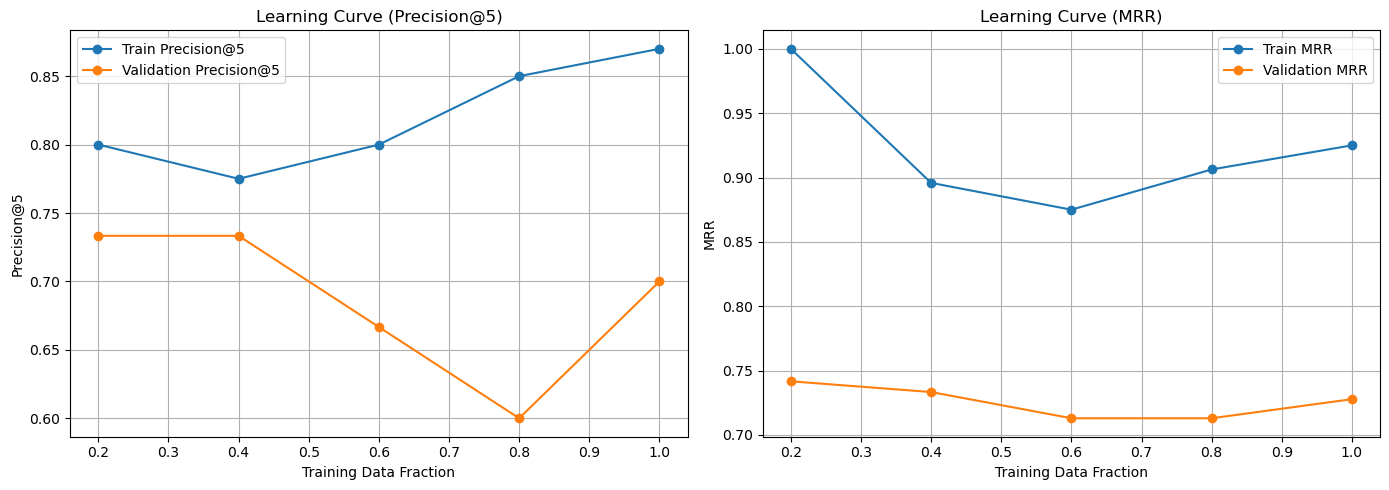

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Plot 1: Precision@10 --------
axes[0].plot(train_sizes, train_p5, marker='o', label='Train Precision@5')
axes[0].plot(train_sizes, val_p5, marker='o', label='Validation Precision@5')

axes[0].set_xlabel("Training Data Fraction")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Learning Curve (Precision@5)")
axes[0].legend()
axes[0].grid(True)

# -------- Plot 2: MRR --------
axes[1].plot(train_sizes, train_mrrs, marker='o', label='Train MRR')
axes[1].plot(train_sizes, val_mrrs, marker='o', label='Validation MRR')

axes[1].set_xlabel("Training Data Fraction")
axes[1].set_ylabel("MRR")
axes[1].set_title("Learning Curve (MRR)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [41]:
mrr_v = mean_reciprocal_rank(rank(X_val,y_val,cv_val,final_model))
mrr_test = mean_reciprocal_rank(rank(X_test,y_test,cv_test,final_model))
mrr_train = mean_reciprocal_rank(rank(X_train,y_train,cv_train,final_model))

per_v = precision_at_k(rank(X_val,y_val,cv_val,final_model),k=10)
per_test = precision_at_k(rank(X_test,y_test,cv_test,final_model),k=10)
per_train = precision_at_k(rank(X_train,y_train,cv_train,final_model),k=10
                           )

print(f"val {mrr_v}, size:{X_val.shape[0]}")
print(f"test {mrr_test}, size:{X_test.shape[0]}")
print(f"train {mrr_train}, size:{X_train.shape[0]}")

print("-"*100)

print(f"per5 val {per_v}, size:{X_val.shape[0]}")
print(f"per5 test {per_test}, size:{X_test.shape[0]}")
print(f"per5 train {per_train}, size:{X_train.shape[0]}")

val 0.7277777777777779, size:1908
test 0.6974206349206349, size:1908
train 0.925, size:6360
----------------------------------------------------------------------------------------------------
per5 val 0.7000000000000001, size:1908
per5 test 0.6833333333333332, size:1908
per5 train 0.8500000000000002, size:6360


C:\Users\Zakaria\AppData\Local\Temp\ipykernel_12328\636704959.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


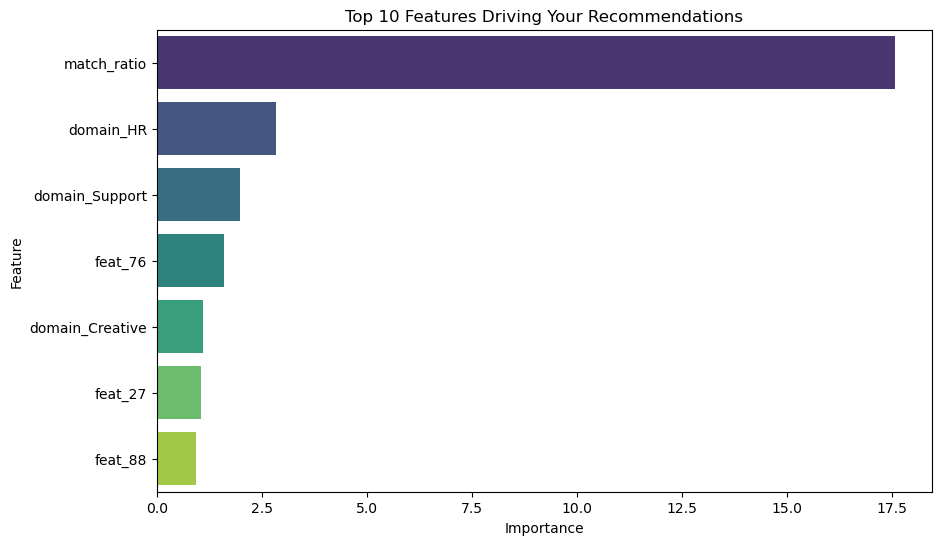

In [42]:

final_model = LogisticRegression(C=100, max_iter=1000, penalty='l2', class_weight='balanced',solver = 'liblinear')
final_model.fit(X_train, y_train)


feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.coef_[0]
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(7)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 10 Features Driving Your Recommendations')
plt.show()
plt.show()

C:\Users\Zakaria\AppData\Local\Temp\ipykernel_12328\2806612160.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


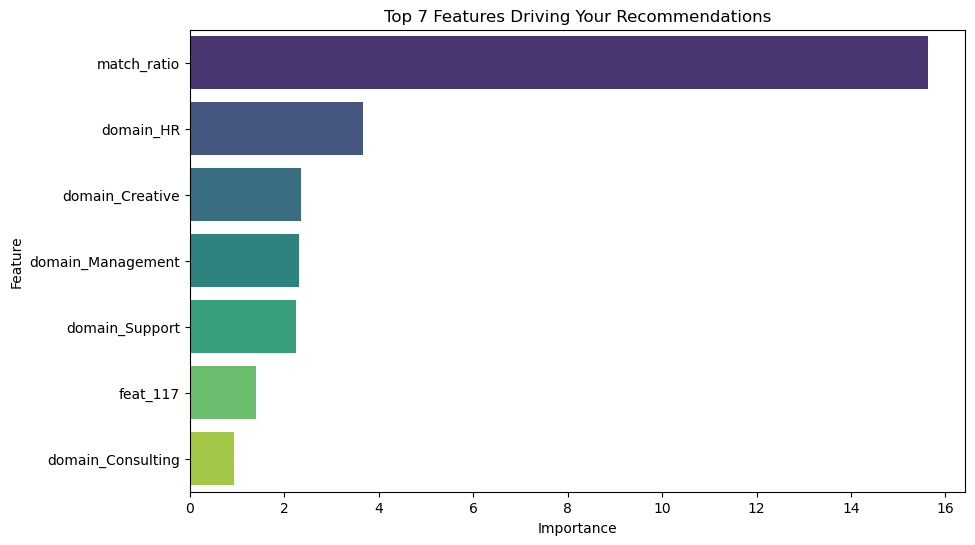

In [43]:
final_model = LogisticRegression(C=100, max_iter=1000, penalty='l2',solver = 'liblinear' ,class_weight='balanced')
final_model.fit(X_val, y_val)


feature_importance = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': final_model.coef_[0]
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(7)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 7 Features Driving Your Recommendations')
plt.show()
plt.show()

In [44]:
def calculate_per_group_metrics(df):
    group_metrics = []

    for cv_id, group in df.groupby('cv_id'):
        acc = accuracy_score(group['actual'], group['predicted'])
        f1 = f1_score(group['actual'], group['predicted'], zero_division=0)
        
 
        group_sorted = group.sort_values(by='score', ascending=False).reset_index(drop=True)
        hit_index = group_sorted[group_sorted['actual'] == 1].index
        mrr = 1.0 / (hit_index[0] + 1) if len(hit_index) > 0 else 0

        group_metrics.append({
            'cv_id': cv_id,
            'accuracy': acc,
            'f1_score': f1,
            'mrr': mrr
        })
    return pd.DataFrame(group_metrics)

def evaluate_set(X, y, cv_ids, model, set_name="Dataset"):
    scores = model.predict_proba(X)[:, 1]
    preds = model.predict(X)

    df_results = pd.DataFrame({
        'cv_id': cv_ids.values,
        'actual': y.values,
        'predicted': preds,
        'score': scores
    })


    metrics_df = calculate_per_group_metrics(df_results)
    

    print(f"\n{'='*10} {set_name} Results {'='*10}")
    print(f"Mean Accuracy: {metrics_df['accuracy'].mean():.4f}")
    print(f"Mean F1 Score: {metrics_df['f1_score'].mean():.4f}")
    print(f"Mean MRR:      {metrics_df['mrr'].mean():.4f}")
    
    return metrics_df, df_results



# 1. Train
train_metrics, train_res = evaluate_set(X_train, y_train, cv_train, final_model, "TRAIN")

# 2. Validation
val_metrics, val_res = evaluate_set(X_val, y_val, cv_val, final_model, "VALIDATION")

# 3. Test
test_metrics, test_res = evaluate_set(X_test, y_test, cv_test, final_model, "TEST")


========== TRAIN Results ==========
Mean Accuracy: 0.7956
Mean F1 Score: 0.4991
Mean MRR:      0.9292

========== VALIDATION Results ==========
Mean Accuracy: 0.9366
Mean F1 Score: 0.5986
Mean MRR:      0.7333

========== TEST Results ==========
Mean Accuracy: 0.7233
Mean F1 Score: 0.3774
Mean MRR:      0.7037


In [45]:
import pickle
filename = "logistic_regression_model.pkl"
pickle.dump(final_model, open(filename, 'wb'))

In [46]:
load_model = pickle.load(open(filename, 'rb'))

In [47]:
load_model

LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                   solver='liblinear')